In [4]:
# imports

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
warnings.filterwarnings('ignore')

%matplotlib inline
#%load_ext cudf.pandas
#supercharges workflow with GPU acceleration using cudf.pandas
#Im having pip install issues with cudf so commenting it out for now

In [5]:
# import the dataset

data = pd.read_csv('Skyserver_CrossID1_13_2026 4_47_50 PM.xlsx - Skyserver_CrossID1_13_2026 4_47.csv')

In [6]:
data.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237680e+18,12.272575,-8.260558,19.37720,17.42771,16.41689,16.00279,15.66193,8095,301,2,381,8.055930e+18,GALAXY,0.113784,7155,56629,418
1,1.237660e+18,177.754301,54.167614,16.55477,16.79530,17.28691,17.57460,17.82930,2821,301,2,174,7.700130e+18,STAR,-0.000640,6839,56425,362
2,1.237650e+18,173.650657,67.873587,18.50882,16.67776,15.88844,15.50315,15.19838,1412,301,5,141,5.540350e+17,GALAXY,0.063698,492,51955,335
3,1.237660e+18,198.419684,47.533219,18.96543,17.71033,17.01655,16.63465,16.37758,3716,301,5,99,1.645040e+18,GALAXY,0.104207,1461,53062,366
4,1.237670e+18,39.922860,29.174099,18.83314,17.17159,16.50847,16.25446,16.11178,5934,301,4,130,2.749590e+18,STAR,-0.000352,2442,54065,524


In [7]:
data.info()
# no null values, 18 columns, 10000 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB


In [8]:
data.columns

Index(['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol',
       'field', 'specobjid', 'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='object')

In [9]:
# Explaining all the columns in the dataset
"""
Column Explanations (Sloan Digital Sky Survey Data):

OBJECT IDENTIFICATION:
- objid: Unique object identifier in SDSS database
- specobjid: Unique spectroscopic object identifier

ASTROMETRY (Position in Sky):
- ra: Right Ascension in degrees (0-360°) - longitude coordinate on celestial sphere
- dec: Declination in degrees (-90 to +90°) - latitude coordinate on celestial sphere

PHOTOMETRY (Brightness Measurements):
- u, g, r, i, z: Magnitudes (brightness) in 5 different photometric bands
  * u: ultraviolet band
  * g: green band
  * r: red band
  * i: near-infrared band
  * z: infrared band
  * Lower magnitude = brighter object

SURVEY IDENTIFIERS (Data Collection Info):
- run: Run number identifying the photometric survey pass
- rerun: Rerun number for the data reduction/processing version
- camcol: Camera column (1-6) identifying which of 6 cameras captured the object
- field: Field number within the run

SPECTROSCOPY (Detailed Light Analysis):
- plate: Plate number from the spectrograph (used to identify which spectroscopic plate)
- mjd: Modified Julian Date - observation date in modified Julian Date format
- fiberid: Fiber identification number on the spectrographic plate (1-640)

CLASSIFICATION:
- class: Object type classification (e.g., 'STAR', 'GALAXY', 'QSO' - Quasi-Stellar Object)
- redshift: Redshift value (z) - indicates how much light is shifted due to universe expansion
  * Measures recession velocity; higher = more distant/faster recession
"""

"\nColumn Explanations (Sloan Digital Sky Survey Data):\n\nOBJECT IDENTIFICATION:\n- objid: Unique object identifier in SDSS database\n- specobjid: Unique spectroscopic object identifier\n\nASTROMETRY (Position in Sky):\n- ra: Right Ascension in degrees (0-360°) - longitude coordinate on celestial sphere\n- dec: Declination in degrees (-90 to +90°) - latitude coordinate on celestial sphere\n\nPHOTOMETRY (Brightness Measurements):\n- u, g, r, i, z: Magnitudes (brightness) in 5 different photometric bands\n  * u: ultraviolet band\n  * g: green band\n  * r: red band\n  * i: near-infrared band\n  * z: infrared band\n  * Lower magnitude = brighter object\n\nSURVEY IDENTIFIERS (Data Collection Info):\n- run: Run number identifying the photometric survey pass\n- rerun: Rerun number for the data reduction/processing version\n- camcol: Camera column (1-6) identifying which of 6 cameras captured the object\n- field: Field number within the run\n\nSPECTROSCOPY (Detailed Light Analysis):\n- plate:

In [10]:
# creating a u_g column which represents the temperature of the stars by doing u-g
data['u_g'] = data['u'] - data['g']

In [11]:
# print the column
data['u_g']

0       1.94949
1      -0.24053
2       1.83106
3       1.25510
4       1.66155
         ...   
9995    0.96303
9996    0.24427
9997    1.86217
9998    1.71798
9999    1.21473
Name: u_g, Length: 10000, dtype: float64

In [12]:
data['u_g'].describe()

count    10000.000000
mean         1.220840
std          0.527874
min         -2.665940
25%          0.973315
50%          1.231510
75%          1.567250
max          3.421020
Name: u_g, dtype: float64

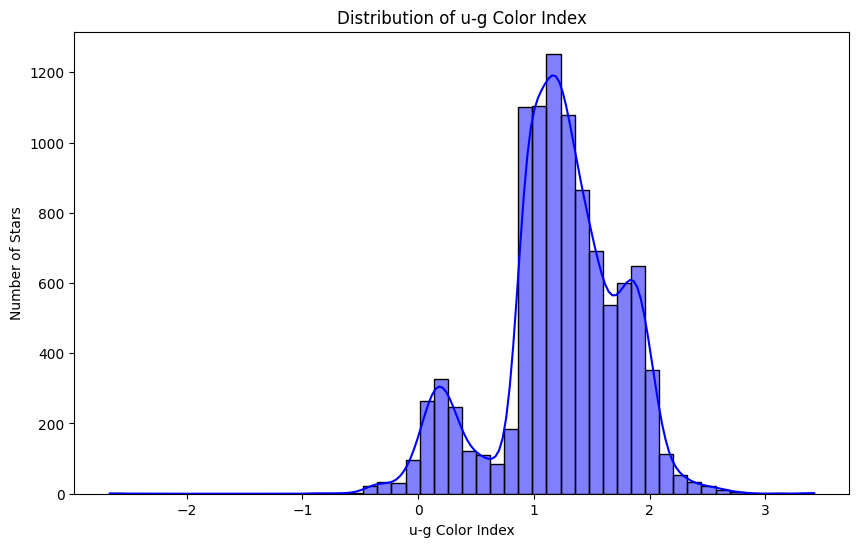

In [13]:
# Exploratory Data Analysis (EDA) on u_g column
plt.figure(figsize=(10,6))
sns.histplot(data['u_g'], bins=50, kde=True, color='blue')
plt.title('Distribution of u-g Color Index')
plt.xlabel('u-g Color Index')
plt.ylabel('Number of Stars')
plt.show()

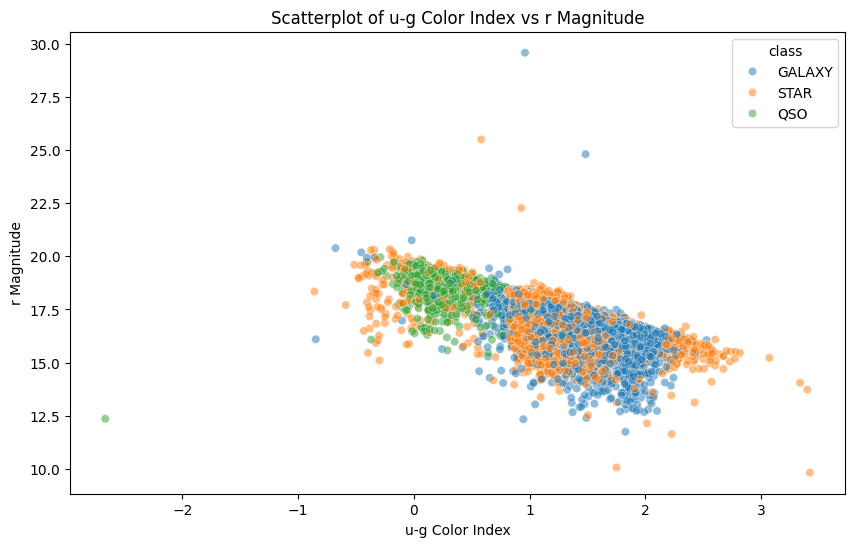

In [14]:
# scatterplot of u_g and r as X and Y axis respectively
plt.figure(figsize=(10,6))
sns.scatterplot(x='u_g', y='r', data=data, alpha=0.5, hue='class')
plt.title('Scatterplot of u-g Color Index vs r Magnitude')
plt.xlabel('u-g Color Index')
plt.ylabel('r Magnitude')
plt.show()

In [15]:
# Analyze u_g and r ranges to determine classification thresholds
print("u_g Statistics:")
print(data['u_g'].describe())
print("\nr Magnitude Statistics:")
print(data['r'].describe())
print("\nClass Distribution:")
print(data['class'].value_counts())

u_g Statistics:
count    10000.000000
mean         1.220840
std          0.527874
min         -2.665940
25%          0.973315
50%          1.231510
75%          1.567250
max          3.421020
Name: u_g, dtype: float64

r Magnitude Statistics:
count    10000.000000
mean        16.898251
std          1.137658
min          9.822070
25%         16.205220
50%         16.907610
75%         17.592013
max         29.571860
Name: r, dtype: float64

Class Distribution:
class
GALAXY    4886
STAR      4055
QSO       1059
Name: count, dtype: int64


In [16]:
# Analyze distribution by object class to understand patterns
print("u_g distribution by class:")
for obj_class in data['class'].unique():
    subset = data[data['class'] == obj_class]['u_g']
    print(f"\n{obj_class}:")
    print(f"  Mean: {subset.mean():.3f}")
    print(f"  Std: {subset.std():.3f}")
    print(f"  Min: {subset.min():.3f}, Max: {subset.max():.3f}")

print("\n" + "="*50)
print("r distribution by class:")
for obj_class in data['class'].unique():
    subset = data[data['class'] == obj_class]['r']
    print(f"\n{obj_class}:")
    print(f"  Mean: {subset.mean():.3f}")
    print(f"  Std: {subset.std():.3f}")
    print(f"  Min: {subset.min():.3f}, Max: {subset.max():.3f}")

u_g distribution by class:

GALAXY:
  Mean: 1.450
  Std: 0.372
  Min: -0.847, Max: 2.529

STAR:
  Mean: 1.189
  Std: 0.448
  Min: -0.859, Max: 3.421

QSO:
  Mean: 0.284
  Std: 0.318
  Min: -2.666, Max: 2.029

r distribution by class:

GALAXY:
  Mean: 16.612
  Std: 0.951
  Min: 11.747, Max: 29.572

STAR:
  Mean: 16.825
  Std: 1.078
  Min: 9.822, Max: 25.496

QSO:
  Mean: 18.502
  Std: 0.789
  Min: 12.358, Max: 19.956


In [17]:
# Manual Star Classifier Function
# Based on analysis:
# - QSO: Very blue (u_g < 0.7), faint (r > 17.5)
# - Blue Stars: Blue (u_g < 0.9), bright (r < 17)
# - Red/White Dwarfs: Red (u_g > 1.5), bright (r < 17)

def classify_star(row):
    """
    Manually classify celestial objects based on color (u-g) and brightness (r).
    
    Logic:
    - Blue: u_g < 0.9 and r < 17.5 (hot, young stars)
    - Dwarf: u_g > 1.3 and r < 17 (white dwarfs - small, hot remnants)
    - Red: Everything else (cooler, older objects)
    """
    u_g = row['u_g']
    r = row['r']
    
    # Blue stars: very blue color and moderately bright
    if u_g < 0.9 and r < 17.5:
        return 'Blue'
    # White Dwarfs: red color but surprisingly bright (small, dense, hot remnants)
    elif u_g > 1.3 and r < 17:
        return 'Dwarf'
    # Red Giants: redder color, generally fainter
    else:
        return 'Red'

# Apply the classifier to create a new column
data['manual_class'] = data.apply(classify_star, axis=1)

# Check the distribution
print("Manual Classification Distribution:")
print(data['manual_class'].value_counts())
print("\nComparison with actual class:")
print(pd.crosstab(data['manual_class'], data['class']))

Manual Classification Distribution:
manual_class
Red      6078
Dwarf    3579
Blue      343
Name: count, dtype: int64

Comparison with actual class:
class         GALAXY  QSO  STAR
manual_class                   
Blue              93   75   175
Dwarf           2453   21  1105
Red             2340  963  2775


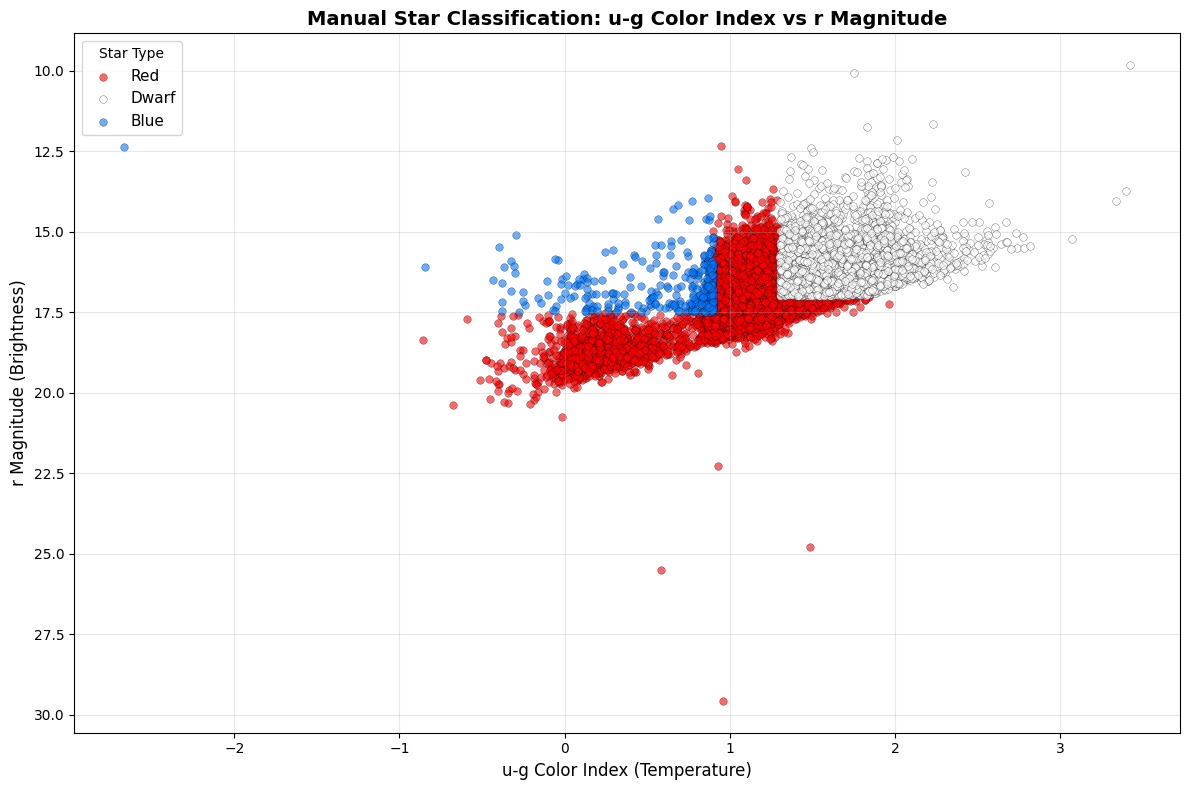

Classification Legend:
- Blue: Hot, young, bright stars (u_g < 0.9, r < 17.5)
- Dwarf: White dwarfs - dense remnants (u_g > 1.3, r < 17)
- Red: Cooler, older objects or galaxies (everything else)


In [18]:
# Visualize the manual classification
plt.figure(figsize=(12, 8))

# Create scatter plot with manual classification
colors = {'Blue': '#0077FF', 'Dwarf': '#FFFFFF', 'Red': '#FF0000'}
for classification in ['Red', 'Dwarf', 'Blue']:  # Plot Red first so Blue is on top
    mask = data['manual_class'] == classification
    plt.scatter(data[mask]['u_g'], data[mask]['r'], 
               c=colors[classification], label=classification, 
               alpha=0.6, s=30, edgecolors='black', linewidth=0.3)

plt.title('Manual Star Classification: u-g Color Index vs r Magnitude', fontsize=14, fontweight='bold')
plt.xlabel('u-g Color Index (Temperature)', fontsize=12)
plt.ylabel('r Magnitude (Brightness)', fontsize=12)
plt.legend(title='Star Type', fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()  # Invert y-axis so brighter (lower magnitude) is on top
plt.tight_layout()
plt.show()

print("Classification Legend:")
print("- Blue: Hot, young, bright stars (u_g < 0.9, r < 17.5)")
print("- Dwarf: White dwarfs - dense remnants (u_g > 1.3, r < 17)")
print("- Red: Cooler, older objects or galaxies (everything else)")